<img src="images/m-rainbow.svg" width="5%" height="5%">

<h1 style="font-size: 30px; font-weight: bold; color: #ff2f05;">
  The Mistral AI Python SDK
</h1>

<h2 style="font-size: 25px; font-weight: bold; color: #fb6227;">
  12. Embeddings
</h2>

In [ ]:
%pip install scikit-learn pandas mistralai python-dotenv matplotlib chromadb

### **12.1 PART 1: Embeddings in the Mistral Python SDK**

#### **12.1.1 What is an embedding?**

**Embeddings are numerical vector representations of data** (e.g. words, sentences, images) that capture their meaning and relationships.

Similar items are located close together in the **vector space**, while unrelated items are farther apart.

This enables **semantic similarity** calculations using measures such as cosine similarity, allowing retrieval based on meaning rather than exact keyword matches.

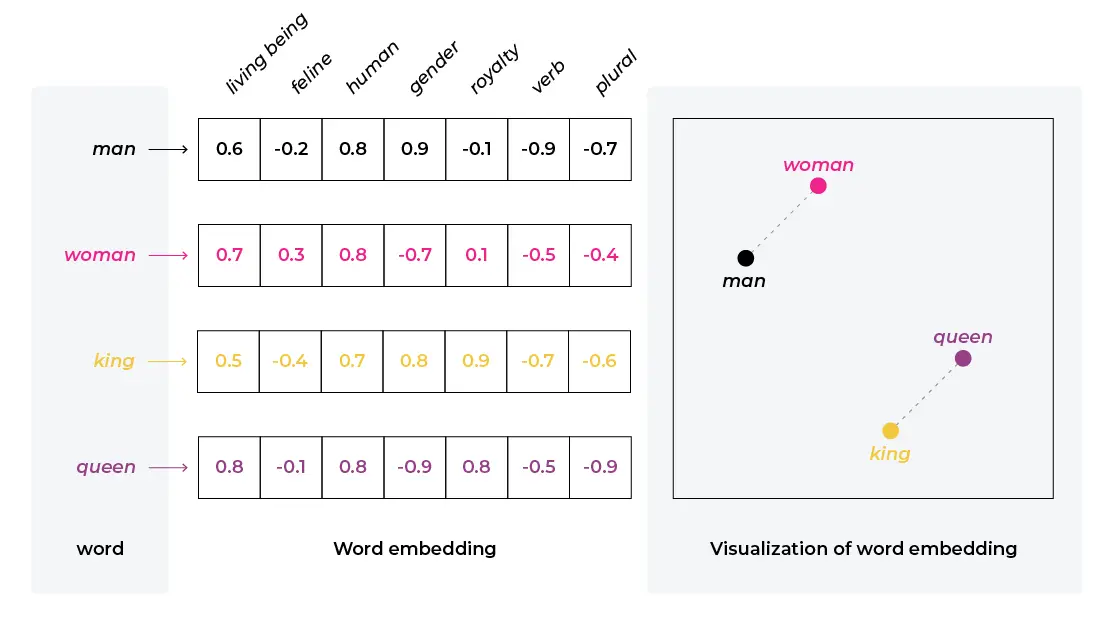

https://arize.com/blog-course/embeddings-meaning-examples-and-how-to-compute/

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

words = ["coding", "computer", "kitchen", "carrot", "sun"]

# Dummy embeddings with 3 dimensions
embeddings = np.array([
    [0.90, 0.85, 0.80],  # coding
    [0.95, 0.80, 0.75],  # computer
    [0.30, 0.60, 0.40],  # kitchen
    [0.25, 0.55, 0.35],  # carrot
    [0.80, 0.20, 0.10],  # sun
])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

# Plot points
ax.scatter(
    embeddings[:, 0],
    embeddings[:, 1],
    embeddings[:, 2],
    s=200,
    c="yellow",
)

# Add labels
for index, word in enumerate(words):
    ax.text(
        embeddings[index, 0],
        embeddings[index, 1],
        embeddings[index, 2],
        word,
        fontsize=12
    )

ax.set_title("Vector Space")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.set_zlabel("Dimension 3")

plt.show()

Embedding models usually use a few hundreds dimensions for their vectors (e.g. 1536 for OpenAI `text-embedding-ada-002` model, 1024 for `mistral-embded` etc)

It is also important to note that there are several ways of measuring the distance between 2 vectors.

Cosine similarity is a popular one for text embeddings.

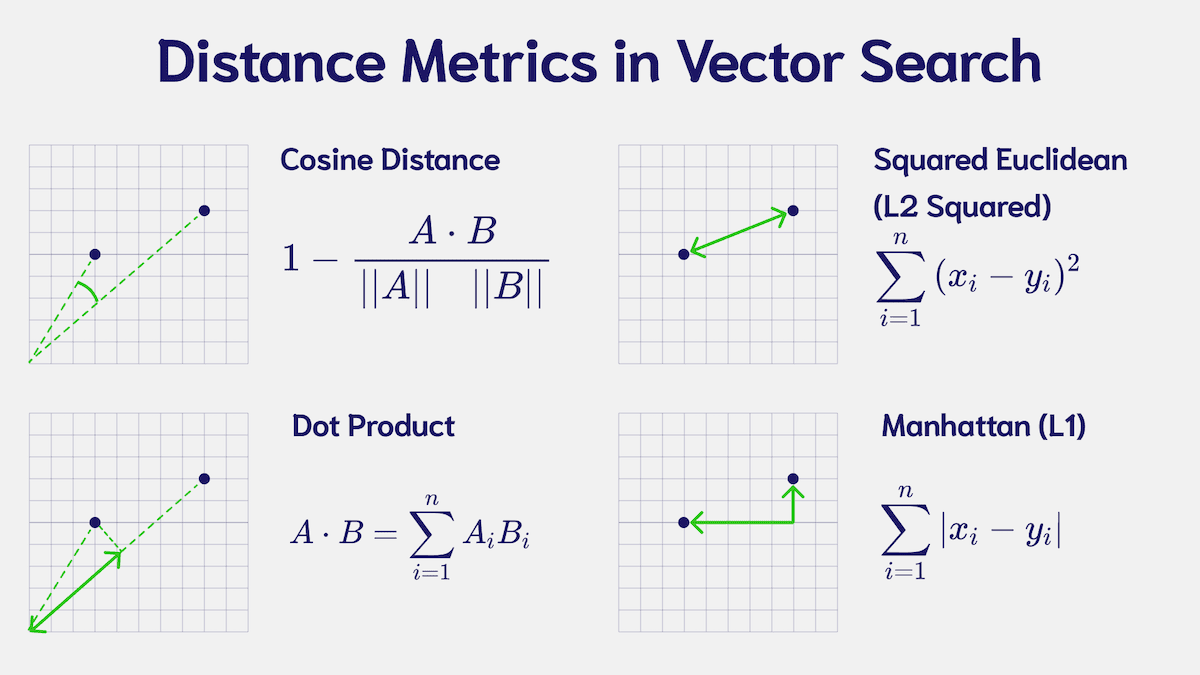

https://weaviate.io/blog/distance-metrics-in-vector-search

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

similarities = cosine_similarity(embeddings)

df_similarity = pd.DataFrame(
    similarities,
    index=words,
    columns=words
)

print(df_similarity.round(3))

#### **12.1.2 Embeddings in the Mistral Python SDK**

In [ ]:
from mistralai.client import Mistral
from dotenv import load_dotenv
import os

load_dotenv()
mistral = Mistral(api_key=os.environ["MISTRAL_API_KEY"])

In [ ]:
documents = [
    # Document 1
    "# FINANCIAL SUMMARY (Q1-2026)\n"
    "Total automotive revenues reached $16,234 million in Q1-2026, a 16% increase YoY compared to $13,967 million in Q1-2025. "
    "Cash, cash equivalents, and short-term investments totaled $44,743 million.",

    # Document 2
    "# OPERATIONAL INFRASTRUCTURE & AI COMPUTE\n"
    "Cortex 2 AI Training Compute infrastructure is now online and running training workloads in Texas, featuring >130k H100e GPUs in early ramp. "
    "Unsupervised Robotaxi rides officially launched in Dallas and Houston."
]

response = mistral.embeddings.create(
    model="mistral-embed",
    inputs=documents
)

response

In [ ]:
response.data

In [ ]:
embeddings = [data.embedding for data in response.data]
print(embeddings)

In [ ]:
similarities = cosine_similarity(embeddings)
similarities

In [ ]:
question = "How much sales have they reached?"

response = mistral.embeddings.create(
    model="mistral-embed",
    inputs=[question]
)

embedded_question = response.data[0].embedding
embeddings.append(embedded_question)
similarities = cosine_similarity(embeddings)
similarities

In [ ]:
index_most_similar = similarities[2][:2].argmax()
index_most_similar

In [ ]:
documents[index_most_similar]

### **12.2 Embeddings in a ChromaDB Vector Database**

#### **12.2.1 ChromaDB Client**

Instead of comparing vectors manually in Python, the vector database handles storage, indexing, and similarity retrieval for you.

| Benefit | Description |
| ---------- | ---------- |
| Optimized for vectors | The database stores high-dimensional embeddings and uses specialized vector indexes.Fast retrieval even with millions of vectors |
| Embed data on upload | Documents, PDFs, emails, images, etc. are converted into embeddings when ingested.Embeddings are computed once and ready for future searches.|
| Embed the query | User questions are converted into embeddings using the same model.Query and stored data exist in the same semantic space. |
| Built-in similarity search | The database automatically finds the nearest vectors using cosine similarity or other distance metrics.No need to compare the query against every vector manually. |

Our first step is to create a client.

You can use:

- `chromadb.Client()` for an in-memory database: data will be lost when your notebook session terminates
- `chromadb.PersistentClient(path="./chroma")` for persistence on your disk

In [1]:
import chromadb

chroma_client = chromadb.Client()

#### **12.2.2 Create the Mistral Embedding Function**

---

Our next step is to create a **collection** in which to store our **documents**.

We will also provide an **embedding function** so we don't rely on the local option. This function will be used:
- To embed our documents when we store them
- To embed our search query when we search for similar documents

---

ChromaDB normally has a [prebuilt class for Mistral embeddings](https://docs.trychroma.com/integrations/embedding-models/mistral) but it does not seem to work with the latest Mistral AI Python SDK at the moment (06/2026).

```python
        from chromadb.utils.embedding_functions import MistralEmbeddingFunction

        mistral_ef  = MistralEmbeddingFunction(
            model="mistral-embed"
        )
```

---



However, they provide a [code sample](https://docs.trychroma.com/docs/embeddings/embedding-functions#custom-embedding-functions), explaining how to create your own embedding function.

This is what we will use to integrate our Mistral model:

In [2]:
from mistralai.client import Mistral
import os
from typing import Dict, Any
from chromadb import Documents, EmbeddingFunction, Embeddings
from chromadb.utils.embedding_functions import register_embedding_function

@register_embedding_function
class MyEmbeddingFunction(EmbeddingFunction):

    # Added the default model and the client
    def __init__(self, model: str = "mistral-embed"):
        self.model = model
        self.client = Mistral(api_key=os.environ.get("MISTRAL_API_KEY"))

    # Modified the method here
    def __call__(self, input: Documents) -> Embeddings:
        response = self.client.embeddings.create(
            model=self.model,
            inputs=input
        )
        return [data.embedding for data in response.data]

    @staticmethod
    def name() -> str:
        return "my-ef"

    def get_config(self) -> Dict[str, Any]:
        return dict(model=self.model)

    @staticmethod
    def build_from_config(config: Dict[str, Any]) -> "EmbeddingFunction":
        return MyEmbeddingFunction(config['model'])

In [3]:
# Test the function
ef = MyEmbeddingFunction()
ef(["first document", "second document"])

[array([-0.0231781 ,  0.02503967,  0.02182007, ...,  0.01357269,
        -0.02938843,  0.00511551], shape=(1024,), dtype=float32),
 array([-0.02932739,  0.03588867,  0.01618958, ...,  0.00486755,
         0.00514221, -0.00101185], shape=(1024,), dtype=float32)]

#### **12.2.3 Create Collection and Add Documents**

We are now ready to create our first collection.

In [4]:
collection = chroma_client.get_or_create_collection(
    name="regulations",
    embedding_function=MyEmbeddingFunction()
)

In [5]:
documents = [
    # HR Documents
    "All full-time employees accrue 2.0 days of paid time off (PTO) per completed calendar month of service, totaling 24 days annually. Unused leave up to a maximum of 5 days may be carried over to the next calendar year, but must be utilized before March 31st or it will be forfeited without financial compensation.",
    "The parental leave policy grants up to 14 weeks of fully paid leave for primary caregivers following childbirth or adoption. Secondary caregivers are eligible for 4 weeks of paid leave. Applications must be submitted to the HR benefits team at least 60 days prior to the expected leave start date.",
    "The corporate employee referral program awards a gross bonus of 1,500 EUR to any staff member who refers a candidate successfully hired for an open full-time position. The bonus is paid out in two equal installments: 50% upon the hire's start date, and 50% upon successful completion of their 6-month probationary period.",
    "Health and wellness benefits include a monthly subsidy of up to 50 EUR for gym memberships, fitness classes, or mental health applications. Receipts must be uploaded to the HR portal under the 'Wellness' category by the last day of each quarter to qualify for reimbursement.",

    # Finance Documents
    "Invoices from external vendors must be issued with standard Net 30 payment terms unless an alternative arrangement has been explicitly approved in writing by the Procurement Director. All invoices must clearly state a valid corporate Purchase Order (PO) number to be processed by Accounts Payable.",
    "Capital expenditure (CapEx) requests exceeding 10,000 EUR require a formal business case presentation to the Finance Committee. The business case must include a detailed Return on Investment (ROI) calculation, a risk assessment matrix, and quotes from at least three independent suppliers.",
    "The corporate credit card policy restricts usage strictly to authorized business expenses. Cardholders are prohibited from charging personal items, cash advances, or unauthorized luxury upgrades. Monthly expense reconciliations, including all itemized receipts, must be finalized by the 5th business day of the following month.",
    "Annual departmental budget submissions are due by October 15th for the upcoming fiscal year. Managers must utilize the standard rolling-forecast template. Proposed budget increases exceeding 5% year-over-year must be accompanied by a written justification detailing headcount or strategic scaling needs.",

    # IT Documents
    "The data classification framework categorizes all corporate information into four tiers: Public, Internal, Confidential, and Restricted. Restricted data, including customer PII and cryptographic keys, must be encrypted both at rest and in transit using AES-256 or higher, and access must be reviewed quarterly.",
    "Software procurement and installation: Employees are strictly prohibited from downloading or running unapproved executable files, open-source libraries with restrictive licenses (e.g., AGPL), or browser extensions on corporate machines. All software requests must go through the IT Service Desk catalog.",
    "Incidents affecting production systems are classified into four severity levels. Severity 1 (Critical) incidents denote total loss of core service for multiple clients and carry a target resolution time of under 2 hours. The On-Call Engineering rotation must be alerted via automated paging immediately upon detection.",
    "Corporate email retention policy: To optimize storage and manage compliance risks, all emails and attachments in user mailboxes are automatically archived after 1 year and permanently deleted after 7 years, unless the mailbox is subject to an active, explicit Legal Hold.",

    # Legal Documents
    "All employees, contractors, and third-party vendors must execute a standard Non-Disclosure Agreement (NDA) prior to receiving access to any proprietary systems, source code, or unannounced product roadmaps. Breach of this agreement will result in immediate termination and potential legal action.",
    "Our anti-bribery and corruption policy strictly prohibits offering, giving, soliciting, or accepting anything of value to improperly influence a business outcome or government official. Gifts to clients or partners must not exceed a nominal value of 50 EUR and must be logged in the Compliance Register.",
    "Whistleblower Protection: Employees may report suspected financial fraud, ethical breaches, or safety violations anonymously through the third-party compliance hotline. The company guarantees protection against retaliation, demotion, or harassment for any report made in good faith.",

    # Engineering Documents
    "The software development lifecycle (SDLC) dictates that no code may be merged into the master branch without passing automated linting, unit tests (minimum 80% coverage required), and receiving approval from at least one senior peer reviewer via a Pull Request.",
    "API Design Guidelines: All internal and external services must expose RESTful endpoints utilizing JSON for payloads. Endpoint paths must use lowercase kebab-case and plural nouns for resources (e.g., /api/v1/user-profiles). Versioning via the URL path is mandatory.",

    # Marketing Documents
    "Brand Identity Guidelines: The primary corporate logo must always maintain a minimum clear space equal to half the height of the logotype itself. The official corporate color palette consists of Deep Navy (Hex #0B1B3D), Slate Gray (Hex #5A6B7C), and Accent Teal (Hex #00A896).",
    "Press Relations Policy: Only designated executive spokespersons and the corporate communications team are authorized to provide statements, interviews, or commentary to members of the media. All ad-hoc media inquiries must be immediately forwarded to press@corporate.com.",

    # Facilities & Operations Documents
    "Physical security controls require all employees and visitors to visibly display their corporate identification badges at all times while on company premises. Tailgating—entering a secured door behind someone without scanning a badge—is a violation of facilities policy."
]

# The list must have the same size as the documents list
ids = [
    "hr_pto", "hr_parental", "hr_referral", "hr_wellness",
    "fin_invoices", "fin_capex", "fin_credit_card", "fin_budget",
    "it_data_class", "it_software", "it_incidents", "it_email_retention",
    "leg_nda", "leg_anti_bribery", "leg_whistleblower",
    "eng_sdlc", "eng_api_design",
    "mkt_brand", "mkt_press",
    "ops_physical_security"
]

# Optional but very helpful in queries
metadatas = [
    {"doc_id": "HR-002", "department": "HR", "status": "active", "version": 2.0, "confidentiality": "Internal"},
    {"doc_id": "HR-003", "department": "HR", "status": "active", "version": 1.1, "confidentiality": "Internal"},
    {"doc_id": "HR-004", "department": "HR", "status": "active", "version": 1.0, "confidentiality": "Internal"},
    {"doc_id": "HR-006", "department": "HR", "status": "under_review", "version": 1.5, "confidentiality": "Internal"},
    {"doc_id": "FIN-001", "department": "Finance", "status": "active", "version": 3.2, "confidentiality": "Internal"},
    {"doc_id": "FIN-005", "department": "Finance", "status": "active", "version": 2.1, "confidentiality": "Confidential"},
    {"doc_id": "FIN-012", "department": "Finance", "status": "active", "version": 1.0, "confidentiality": "Internal"},
    {"doc_id": "FIN-020", "department": "Finance", "status": "under_review", "version": 4.0, "confidentiality": "Confidential"},
    {"doc_id": "IT-101", "department": "IT", "status": "active", "version": 2.4, "confidentiality": "Confidential"},
    {"doc_id": "IT-102", "department": "IT", "status": "active", "version": 1.0, "confidentiality": "Internal"},
    {"doc_id": "IT-204", "department": "IT", "status": "active", "version": 3.0, "confidentiality": "Internal"},
    {"doc_id": "IT-305", "department": "IT", "status": "deprecated", "version": 1.2, "confidentiality": "Confidential"},
    {"doc_id": "LEG-001", "department": "Legal", "status": "active", "version": 2.0, "confidentiality": "Restricted"},
    {"doc_id": "LEG-002", "department": "Legal", "status": "active", "version": 1.1, "confidentiality": "Internal"},
    {"doc_id": "LEG-009", "department": "Legal", "status": "active", "version": 1.0, "confidentiality": "Internal"},
    {"doc_id": "ENG-042", "department": "Engineering", "status": "active", "version": 2.2, "confidentiality": "Internal"},
    {"doc_id": "ENG-088", "department": "Engineering", "status": "active", "version": 1.0, "confidentiality": "Internal"},
    {"doc_id": "MKT-001", "department": "Marketing", "status": "active", "version": 1.0, "confidentiality": "Public"},
    {"doc_id": "MKT-015", "department": "Marketing", "status": "active", "version": 2.1, "confidentiality": "Internal"},
    {"doc_id": "OPS-002", "department": "Operations", "status": "active", "version": 1.3, "confidentiality": "Internal"}
]

In [6]:
collection.add(
    ids=ids,
    documents=documents,
    metadatas=metadatas # optional
)

In [7]:
collection.count()

20

In [8]:
collection.peek(limit=2)

{'ids': ['hr_pto', 'hr_parental'],
 'embeddings': array([[-0.06304932,  0.02484131,  0.03771973, ...,  0.00098038,
          0.00401306,  0.04089355],
        [-0.1005249 ,  0.05102539,  0.01994324, ..., -0.02874756,
          0.00900269,  0.02487183]], shape=(2, 1024)),
 'documents': ['All full-time employees accrue 2.0 days of paid time off (PTO) per completed calendar month of service, totaling 24 days annually. Unused leave up to a maximum of 5 days may be carried over to the next calendar year, but must be utilized before March 31st or it will be forfeited without financial compensation.',
  'The parental leave policy grants up to 14 weeks of fully paid leave for primary caregivers following childbirth or adoption. Secondary caregivers are eligible for 4 weeks of paid leave. Applications must be submitted to the HR benefits team at least 60 days prior to the expected leave start date.'],
 'uris': None,
 'included': ['metadatas', 'documents', 'embeddings'],
 'data': None,
 'metadat

#### **12.2.4 Get Items**

Use `.get` to retrieve records by ID and/or filters without similarity ranking:

In [9]:
collection.get(ids=["it_data_class", "mkt_press"])

{'ids': ['it_data_class', 'mkt_press'],
 'embeddings': None,
 'documents': ['The data classification framework categorizes all corporate information into four tiers: Public, Internal, Confidential, and Restricted. Restricted data, including customer PII and cryptographic keys, must be encrypted both at rest and in transit using AES-256 or higher, and access must be reviewed quarterly.',
  'Press Relations Policy: Only designated executive spokespersons and the corporate communications team are authorized to provide statements, interviews, or commentary to members of the media. All ad-hoc media inquiries must be immediately forwarded to press@corporate.com.'],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'confidentiality': 'Confidential',
   'status': 'active',
   'department': 'IT',
   'doc_id': 'IT-101',
   'version': 2.4},
  {'department': 'Marketing',
   'status': 'active',
   'confidentiality': 'Internal',
   'doc_id': 'MKT-015',
   'versio

#### **12.2.5 Query Collection**

##### **Display Results Function**

In [10]:
from IPython.display import Markdown

def display_chroma_results(results):

    docs = results["documents"][0]
    metadatas = results["metadatas"][0]
    ids = results["ids"][0]
    distances = results["distances"][0]

    md_content = "---\n"

    for i in range(len(docs)):

        distance = f" (Distance: {distances[i]:.4f})"
        md_content += f"#### Match #{i+1}: `{ids[i]}` {distance}\n"
        
        # Metadata
        md_content += "**Metadata:**\n"
        md_content += f"```python\n{metadatas[i]}\n```\n"
        
        # Document
        md_content += "**Document Content:**\n"
        md_content += f"> {docs[i]}\n\n"
        
        md_content += "---\n"

    return Markdown(md_content)

##### **Simple Semantic Search**

[Documentation](https://docs.trychroma.com/docs/querying-collections/query-and-get#query): Chroma will use the collection’s embedding function to embed your text queries, and use the output to run a vector similarity search against your collection.

In [11]:
# Simple semantic search
results = collection.query(
    query_texts=["I'm having a baby soon, what are my options?"],
    n_results=1
)

results

{'ids': [['hr_parental']],
 'embeddings': None,
 'documents': [['The parental leave policy grants up to 14 weeks of fully paid leave for primary caregivers following childbirth or adoption. Secondary caregivers are eligible for 4 weeks of paid leave. Applications must be submitted to the HR benefits team at least 60 days prior to the expected leave start date.']],
 'uris': None,
 'included': ['metadatas', 'documents', 'distances'],
 'data': None,
 'metadatas': [[{'version': 1.1,
    'department': 'HR',
    'confidentiality': 'Internal',
    'doc_id': 'HR-003',
    'status': 'active'}]],
 'distances': [[0.7080731987953186]]}

In [12]:
print(results["documents"][0][0])

The parental leave policy grants up to 14 weeks of fully paid leave for primary caregivers following childbirth or adoption. Secondary caregivers are eligible for 4 weeks of paid leave. Applications must be submitted to the HR benefits team at least 60 days prior to the expected leave start date.


In [13]:
print(results["metadatas"][0][0])

{'version': 1.1, 'department': 'HR', 'confidentiality': 'Internal', 'doc_id': 'HR-003', 'status': 'active'}


In [14]:
print(results["ids"][0][0])

hr_parental


In [15]:
print(results["distances"][0][0])

0.7080731987953186


---
**What about indices [0][0]?**

- The First Index `[0]` selects which query you are looking at (as you may pass multiple queries to `query_texts`)
- The Second Index `[0]` selects which result you want to retrieve (max index is `n_results` - 1)

---
**Example**

Imagine you submitted two different questions at the same time and asked for 3 results for each: 
- query_texts=["Question A", "Question B"]
- n_results=3.

The results["documents"] matrix would look like this:

```python
results["documents"] = [
    ["Match #1 for Q1", "Match #2 for Q1", "Match #3 for Q1"],  # <-- Index [0] (First Query)
    ["Match #1 for Q2", "Match #2 for Q2", "Match #3 for Q2"]   # <-- Index [1] (Second Query)
]
```
---

In [16]:
# With multiple matches

n = 3

results = collection.query(
    query_texts=["How do we keep our data and assets safe from intruders?"],
    n_results=n
)

for i in range(n):
    id = results["ids"][0][i]
    doc = results["documents"][0][i]
    print(f"ID {id}: {doc}\n")

ID it_data_class: The data classification framework categorizes all corporate information into four tiers: Public, Internal, Confidential, and Restricted. Restricted data, including customer PII and cryptographic keys, must be encrypted both at rest and in transit using AES-256 or higher, and access must be reviewed quarterly.

ID ops_physical_security: Physical security controls require all employees and visitors to visibly display their corporate identification badges at all times while on company premises. Tailgating—entering a secured door behind someone without scanning a badge—is a violation of facilities policy.

ID leg_nda: All employees, contractors, and third-party vendors must execute a standard Non-Disclosure Agreement (NDA) prior to receiving access to any proprietary systems, source code, or unannounced product roadmaps. Breach of this agreement will result in immediate termination and potential legal action.



##### **Simple Metadata Filtering**

Use the following structure to filter on metadata:

```python
{
    "metadata_field": "search_string"
}
```

In [17]:
results = collection.query(
      query_texts=["How do I get paid back for buying things?"],
      n_results=2,
      where={"department": "Finance"}
  )

display_chroma_results(results)

---
#### Match #1: `fin_invoices`  (Distance: 0.7119)
**Metadata:**
```python
{'status': 'active', 'version': 3.2, 'department': 'Finance', 'doc_id': 'FIN-001', 'confidentiality': 'Internal'}
```
**Document Content:**
> Invoices from external vendors must be issued with standard Net 30 payment terms unless an alternative arrangement has been explicitly approved in writing by the Procurement Director. All invoices must clearly state a valid corporate Purchase Order (PO) number to be processed by Accounts Payable.

---
#### Match #2: `fin_credit_card`  (Distance: 0.7119)
**Metadata:**
```python
{'status': 'active', 'version': 1.0, 'doc_id': 'FIN-012', 'department': 'Finance', 'confidentiality': 'Internal'}
```
**Document Content:**
> The corporate credit card policy restricts usage strictly to authorized business expenses. Cardholders are prohibited from charging personal items, cash advances, or unauthorized luxury upgrades. Monthly expense reconciliations, including all itemized receipts, must be finalized by the 5th business day of the following month.

---


##### **Metadata Filtering with Operators**

Use the following structure to include operators in your metadata filters:

```python
{
    "metadata_field": {
        <Operator>: <Value>
    }
}
```

| Operator | Meaning |
| ----- | ----- |
| $eq | Equal to |
| $ne | Not Equal to |
| $lt | Lower Than |
| $lte | Lower Than or Equal to |
| $gt | Greater Than |
| $gte | Greater Than or Equal to |

In [18]:
results = collection.query(
      query_texts=["What are the guidelines for writing code?"],
      n_results=1,
      where={"version": {"$gte": 2.0}}
  )

display_chroma_results(results)

---
#### Match #1: `eng_sdlc`  (Distance: 0.5258)
**Metadata:**
```python
{'version': 2.2, 'department': 'Engineering', 'status': 'active', 'confidentiality': 'Internal', 'doc_id': 'ENG-042'}
```
**Document Content:**
> The software development lifecycle (SDLC) dictates that no code may be merged into the master branch without passing automated linting, unit tests (minimum 80% coverage required), and receiving approval from at least one senior peer reviewer via a Pull Request.

---


##### **Metadata Filtering  with $AND/$OR Operators**

[Documentation](https://docs.trychroma.com/docs/querying-collections/metadata-filtering#using-logical-operators): You can also use the logical operators `$and` and `$or` to combine multiple filters within an array.

```python
{
    "$and": [
        {
            "metadata_field": {
                <Operator>: <Value>
            }
        },
        {
            "metadata_field": {
                <Operator>: <Value>
            }
        }
    ]
}
```

In [19]:
results = collection.query(
      query_texts=["What is our policy on sharing secrets or passwords?"],
      n_results=2,
      where={
          "$and": [
              {"status": "active"},
              {"confidentiality": {"$ne": "Public"}}
          ]
      }
  )

display_chroma_results(results)

---
#### Match #1: `leg_nda`  (Distance: 0.5716)
**Metadata:**
```python
{'doc_id': 'LEG-001', 'version': 2.0, 'department': 'Legal', 'status': 'active', 'confidentiality': 'Restricted'}
```
**Document Content:**
> All employees, contractors, and third-party vendors must execute a standard Non-Disclosure Agreement (NDA) prior to receiving access to any proprietary systems, source code, or unannounced product roadmaps. Breach of this agreement will result in immediate termination and potential legal action.

---
#### Match #2: `leg_whistleblower`  (Distance: 0.5745)
**Metadata:**
```python
{'status': 'active', 'doc_id': 'LEG-009', 'department': 'Legal', 'confidentiality': 'Internal', 'version': 1.0}
```
**Document Content:**
> Whistleblower Protection: Employees may report suspected financial fraud, ethical breaches, or safety violations anonymously through the third-party compliance hotline. The company guarantees protection against retaliation, demotion, or harassment for any report made in good faith.

---


In [20]:
results = collection.query(
      query_texts=["What are the rules regarding external communications, reporting, or press?"],
      n_results=2,
      where={
          "$or": [
              {"department": "Legal"},
              {"department": "Marketing"}
          ]
      }
  )

display_chroma_results(results)

---
#### Match #1: `mkt_press`  (Distance: 0.4215)
**Metadata:**
```python
{'department': 'Marketing', 'version': 2.1, 'status': 'active', 'confidentiality': 'Internal', 'doc_id': 'MKT-015'}
```
**Document Content:**
> Press Relations Policy: Only designated executive spokespersons and the corporate communications team are authorized to provide statements, interviews, or commentary to members of the media. All ad-hoc media inquiries must be immediately forwarded to press@corporate.com.

---
#### Match #2: `leg_whistleblower`  (Distance: 0.5482)
**Metadata:**
```python
{'department': 'Legal', 'status': 'active', 'doc_id': 'LEG-009', 'version': 1.0, 'confidentiality': 'Internal'}
```
**Document Content:**
> Whistleblower Protection: Employees may report suspected financial fraud, ethical breaches, or safety violations anonymously through the third-party compliance hotline. The company guarantees protection against retaliation, demotion, or harassment for any report made in good faith.

---


##### **Metadata Filtering with Inclusion Operators**

The previous example could have been simplified by using the `$in` operator.

There is also a `$nin` (not in) operator to achieve the inverse result.

In [21]:
results = collection.query(
      query_texts=["What are the rules regarding external communications, reporting, or press?"],
      n_results=2,
      where={
        "department": {"$in": ["Legal", "Marketing"]},
      }
  )

display_chroma_results(results)

---
#### Match #1: `mkt_press`  (Distance: 0.4215)
**Metadata:**
```python
{'status': 'active', 'department': 'Marketing', 'confidentiality': 'Internal', 'doc_id': 'MKT-015', 'version': 2.1}
```
**Document Content:**
> Press Relations Policy: Only designated executive spokespersons and the corporate communications team are authorized to provide statements, interviews, or commentary to members of the media. All ad-hoc media inquiries must be immediately forwarded to press@corporate.com.

---
#### Match #2: `leg_whistleblower`  (Distance: 0.5482)
**Metadata:**
```python
{'doc_id': 'LEG-009', 'department': 'Legal', 'status': 'active', 'version': 1.0, 'confidentiality': 'Internal'}
```
**Document Content:**
> Whistleblower Protection: Employees may report suspected financial fraud, ethical breaches, or safety violations anonymously through the third-party compliance hotline. The company guarantees protection against retaliation, demotion, or harassment for any report made in good faith.

---


##### **Full Text Search**

[Documentation](https://docs.trychroma.com/docs/querying-collections/full-text-search)

The `where_document` argument is used to filter records based on their document content

In [22]:
results = collection.query(
      query_texts=["What are the financial rules?"],
      n_results=2,
      where_document={"$contains": "EUR"},
  )

display_chroma_results(results)

---
#### Match #1: `fin_capex`  (Distance: 0.5803)
**Metadata:**
```python
{'status': 'active', 'department': 'Finance', 'doc_id': 'FIN-005', 'confidentiality': 'Confidential', 'version': 2.1}
```
**Document Content:**
> Capital expenditure (CapEx) requests exceeding 10,000 EUR require a formal business case presentation to the Finance Committee. The business case must include a detailed Return on Investment (ROI) calculation, a risk assessment matrix, and quotes from at least three independent suppliers.

---
#### Match #2: `leg_anti_bribery`  (Distance: 0.6272)
**Metadata:**
```python
{'doc_id': 'LEG-002', 'confidentiality': 'Internal', 'status': 'active', 'version': 1.1, 'department': 'Legal'}
```
**Document Content:**
> Our anti-bribery and corruption policy strictly prohibits offering, giving, soliciting, or accepting anything of value to improperly influence a business outcome or government official. Gifts to clients or partners must not exceed a nominal value of 50 EUR and must be logged in the Compliance Register.

---
